<div dir="ltr" style="text-align: left; line-height:200%; font-family:vazir; font-size:medium">

<h1 align="left" style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
Sina and the Mystery of Tehran's Air</font>
</h1>

Sina is a student and also goes to work at the same time. With the arrival of the cold season and temperature inversion, he checks the news every day, hoping that universities and offices will be closed due to Tehran's air pollution, and his classes and exams will be held virtually so he can get to his tasks from home!

So that Sina can predict the closure status earlier than the news, he has decided to take action and build an AI model. In this problem, hourly data related to air quality and weather conditions in Tehran city has been provided to you. 

Your goal is to help Sina! You must design a model based on machine learning or time series analysis that can predict the concentration of particulate matter (AQI) based on meteorological data so Sina can figure out whether his classes will be virtual or not.

---
</div>

<div dir="ltr" style="text-align: left; line-height:200%; font-family:vazir; font-size:medium">

<h2 align="left" style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
Data Structure
</font>
</h2>

The data for this competition is divided into two parts: the <code>train.csv</code> file contains hourly information from 2022 to the end of 2025, and the <code>test.csv</code> file contains hourly information for the year 2026. The complete list of columns is as follows:

| **Column Name** | **Description** |
| --- | --- |
| `No` | Unique row identifier (record number) |
| `timestamp` | Time and date of record entry as a text string |
| `AQI` | **(Target Variable):** Concentration of particulate matter less than 2.5 microns (contains missing values in the training file) |
| `DEWP` | Dew point (Celsius) |
| `TEMP` | Temperature (Celsius) |
| `TEMP_F` | Temperature (Fahrenheit) |
| `PRES` | Air pressure (hPa) |
| `sensor_voltage` | Measurement sensor voltage at the time of recording (millivolts) |
| `cbwd` | Dominant wind direction |
| `Iws` | Cumulated wind speed (meters per second) |
| `Is` | Cumulated hours of snow |
| `Ir` | Cumulated hours of rain |

---
</div>

<h2 align=left style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
The Dataset
</font>
</h2>


In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

train_df = pd.read_csv('../data/train.csv')
test_df = pd.read_csv('../data/test.csv')

print(f'Train shape: {train_df.shape}')
print(f'Test shape: {test_df.shape}')
print(f'\nTrain AQI missing: {train_df["AQI"].isna().sum()}')
print(f'Train AQI describe:\n{train_df["AQI"].describe()}')

Train shape: (35064, 12)
Test shape: (8661, 11)

Train AQI missing: 1968
Train AQI describe:
count    33096.000000
mean       122.917815
std        937.400853
min       -999.000000
25%         29.000000
50%         73.000000
75%        139.000000
max      47044.000000
Name: AQI, dtype: float64


<h2 align=left style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
Preprocessing
</font>
</h2>


In [2]:
MONTH_MAP = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
    'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}

WIND_MAP = {
    'northwest': 'NW', 'nw': 'NW', 'n_w': 'NW', 'n-w': 'NW', 'NorthWest': 'NW',
    'northeast': 'NE', 'ne': 'NE', 'n_e': 'NE', 'n-e': 'NE', 'NorthEast': 'NE',
    'southwest': 'SW', 'sw': 'SW', 's_w': 'SW', 's-w': 'SW', 'SouthWest': 'SW',
    'southeast': 'SE', 'se': 'SE', 's_e': 'SE', 's-e': 'SE', 'SouthEast': 'SE',
    'cv': 'CV', 'calm': 'CV', 'calm_wind': 'CV',
    'north': 'N', 'south': 'S', 'east': 'E', 'west': 'W',
}

def parse_timestamp(df):
    df = df.copy()
    parts = df['timestamp'].str.split('/')
    df['year'] = parts.str[0].astype(int)
    df['month'] = parts.str[1].map(MONTH_MAP).astype(int)
    day_time = parts.str[2]
    df['day'] = day_time.str.split(' ').str[0].astype(int)
    df['hour'] = day_time.str.split(' ').str[1].str.split(':').str[0].astype(int)
    return df

def encode_wind(df):
    df = df.copy()
    df['cbwd_clean'] = df['cbwd'].str.lower().str.strip().map(WIND_MAP).fillna('Other')
    return df

def add_time_features(df):
    df = df.copy()
    df['day_of_week'] = pd.to_datetime(df[['year','month','day']].assign(hour=df['hour'])).dt.dayofweek
    df['day_of_year'] = pd.to_datetime(df[['year','month','day']].assign(hour=df['hour'])).dt.dayofyear
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    df['season'] = df['month'].map({12:0,1:0,2:0,3:1,4:1,5:1,6:2,7:2,8:2,9:3,10:3,11:3})
    df['is_night'] = ((df['hour'] >= 20) | (df['hour'] <= 5)).astype(int)
    return df

def add_interaction_features(df):
    df = df.copy()
    df['temp_dewp_diff'] = df['TEMP'] - df['DEWP']
    df['humidity_proxy'] = df['DEWP'] / df['TEMP'].replace(0, np.nan)
    df['humidity_proxy'] = df['humidity_proxy'].fillna(0)
    df['temp_pressure_ratio'] = df['TEMP'] / df['PRES'].replace(0, np.nan)
    df['wind_temp_interaction'] = df['Iws'] * df['TEMP']
    return df

def preprocess(df, is_train=True):
    df = parse_timestamp(df)
    df = encode_wind(df)
    df = add_time_features(df)
    df = add_interaction_features(df)
    if is_train:
        df = df[(df['AQI'] >= 0) & (df['AQI'] <= 500)].copy()
    return df

train_df = preprocess(train_df, is_train=True)
test_df = preprocess(test_df, is_train=False)

print(f'Train shape after cleaning: {train_df.shape}')
print(f'Test shape after cleaning: {test_df.shape}')

Train shape after cleaning: (32954, 30)
Test shape after cleaning: (8661, 29)


In [3]:
train_df = train_df.sort_values('No').reset_index(drop=True)

lag_hours = [1, 2, 3, 6, 12, 24, 48]
for lag in lag_hours:
    train_df[f'aqi_lag_{lag}'] = train_df['AQI'].shift(lag)
    test_df[f'aqi_lag_{lag}'] = np.nan

for window in [6, 12, 24]:
    train_df[f'aqi_roll_mean_{window}'] = train_df['AQI'].shift(1).rolling(window=window, min_periods=1).mean()
    train_df[f'aqi_roll_std_{window}'] = train_df['AQI'].shift(1).rolling(window=window, min_periods=1).std()
    test_df[f'aqi_roll_mean_{window}'] = np.nan
    test_df[f'aqi_roll_std_{window}'] = np.nan

for lag in [1, 24]:
    train_df[f'temp_lag_{lag}'] = train_df['TEMP'].shift(lag)
    train_df[f'pres_lag_{lag}'] = train_df['PRES'].shift(lag)
    test_df[f'temp_lag_{lag}'] = np.nan
    test_df[f'pres_lag_{lag}'] = np.nan

print('Lag features created.')

Lag features created.


In [4]:
wind_dummies_train = pd.get_dummies(train_df['cbwd_clean'], prefix='wind')
wind_dummies_test = pd.get_dummies(test_df['cbwd_clean'], prefix='wind')
wind_dummies_test = wind_dummies_test.reindex(columns=wind_dummies_train.columns, fill_value=0)

train_df = pd.concat([train_df, wind_dummies_train], axis=1)
test_df = pd.concat([test_df, wind_dummies_test], axis=1)

print(f'Wind dummies columns: {wind_dummies_train.columns.tolist()}')

Wind dummies columns: ['wind_CV', 'wind_NE', 'wind_NW', 'wind_SE']


<h2 align=left style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
Modeling
</font>
</h2>

<p dir="ltr" style="direction: ltr; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font face="vazir" size="3">
After preparing the data, build and train your regression or time series model to predict the <code>AQI</code> value.
</font>
</p>

In [5]:
feature_cols = [
    'DEWP', 'TEMP', 'TEMP_F', 'PRES', 'sensor_voltage', 'Iws', 'Is', 'Ir',
    'year', 'month', 'day', 'hour', 'day_of_week', 'day_of_year',
    'is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
    'season', 'is_night',
    'temp_dewp_diff', 'humidity_proxy', 'temp_pressure_ratio', 'wind_temp_interaction',
]

lag_cols = [c for c in train_df.columns if 'aqi_lag' in c or 'aqi_roll' in c or 'temp_lag' in c or 'pres_lag' in c]
wind_cols = [c for c in train_df.columns if c.startswith('wind_') and c != 'wind_temp_interaction']

all_features = feature_cols + lag_cols + wind_cols

train_data = train_df.dropna(subset=['AQI'] + lag_cols)

X = train_data[all_features]
y = train_data['AQI']

split_idx = int(len(X) * 0.9)
X_train, X_val = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_val = y.iloc[:split_idx], y.iloc[split_idx:]

print(f'Train samples: {len(X_train)}')
print(f'Val samples: {len(X_val)}')
print(f'Total features: {len(all_features)}')

Train samples: 29615
Val samples: 3291
Total features: 46


In [6]:
lgb_train = lgb.Dataset(X_train, label=y_train)
lgb_val = lgb.Dataset(X_val, label=y_val, reference=lgb_train)

params = {
    'objective': 'regression',
    'metric': 'mae',
    'boosting_type': 'gbdt',
    'num_leaves': 127,
    'learning_rate': 0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'min_child_samples': 20,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'n_estimators': 3000,
    'verbose': -1,
    'n_jobs': -1,
    'seed': 42,
}

callbacks = [
    lgb.early_stopping(stopping_rounds=100, verbose=True),
    lgb.log_evaluation(period=500)
]

model = lgb.train(
    params,
    lgb_train,
    num_boost_round=3000,
    valid_sets=[lgb_train, lgb_val],
    valid_names=['train', 'valid'],
    callbacks=callbacks,
)

val_pred = model.predict(X_val)
val_mae = mean_absolute_error(y_val, val_pred)
print(f'\nValidation MAE: {val_mae:.4f}')

Training until validation scores don't improve for 100 rounds


Early stopping, best iteration is:
[173]	train's l1: 5.40161	valid's l1: 6.93589

Validation MAE: 6.9359


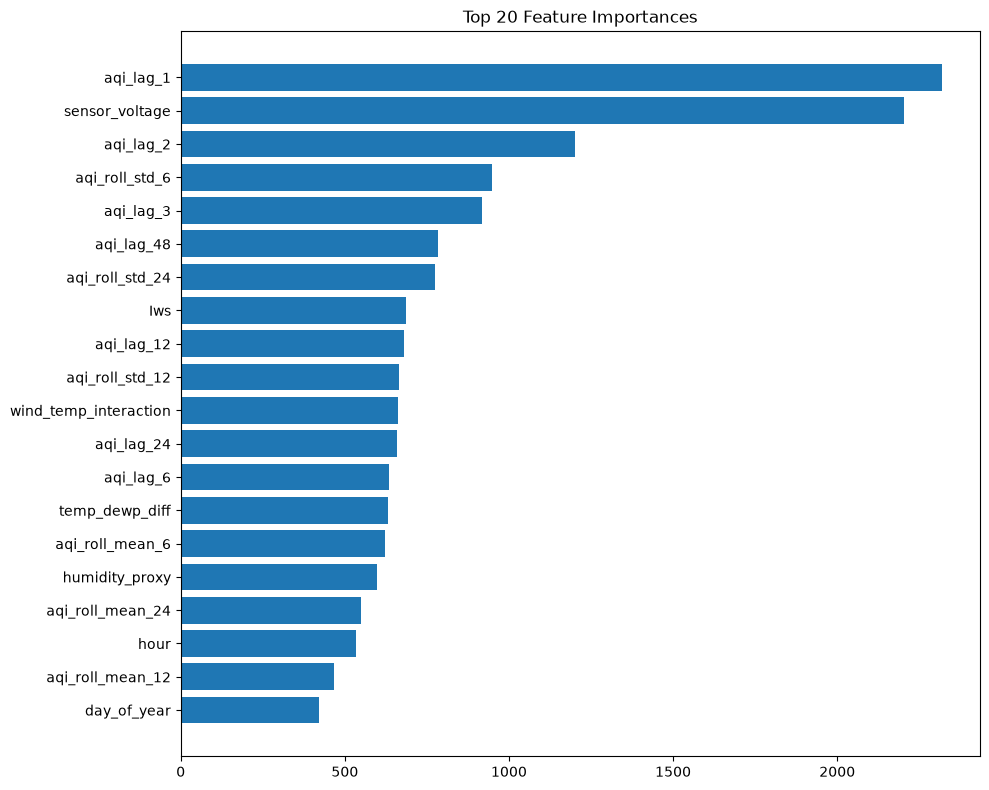

In [7]:
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    'feature': all_features,
    'importance': model.feature_importance()
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(importance['feature'][:20], importance['importance'][:20])
plt.gca().invert_yaxis()
plt.title('Top 20 Feature Importances')
plt.tight_layout()
plt.show()

<div dir="ltr" style="text-align: left; line-height:200%; font-family:vazir; font-size:medium">

<h3 align="left" style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
Preparing the Output File (Submission)
</font>
</h3>

Note that you must save your model's predictions in a file named <code>submission.csv</code> which contains exactly two columns: <code>No</code> and <code>AQI</code>. 

</div>

In [8]:
test_features = test_df[all_features]
test_predictions = model.predict(test_features)
test_predictions = np.clip(test_predictions, 0, 500)

print(f'Test predictions stats:\nMin: {test_predictions.min():.1f}, Max: {test_predictions.max():.1f}, Mean: {test_predictions.mean():.1f}')

submission = pd.DataFrame()
submission['No'] = test_df['No']
submission['AQI'] = test_predictions

submission.head(10)

Test predictions stats:
Min: 4.3, Max: 313.0, Mean: 115.5


,No,AQI
0,35065,111.413429
1,35066,105.189409
2,35067,118.589641
3,35068,120.142395
4,35069,199.515426
5,35070,190.168312
6,35071,165.977464
7,35072,240.409633
8,35073,16.291150
9,35074,81.939047


<h2 align="left" style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
<b>Result Generator Cell</b>
</font>
</h2>

<p dir="ltr" style="direction: ltr; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font face="vazir" size="3">
    Run the cell below to generate the <code>result.zip</code> file.
    <br>
    You must upload the <code>result.zip</code> file in Quera and wait for the judging result!
    <br>
    This file includes <code>submission.csv</code>, this very notebook you are coding in, and your saved model.
</font>
</p>

In [9]:
import zipfile

def compress(file_names):
    print("File Paths:")
    print(file_names)
    compression = zipfile.ZIP_DEFLATED
    with zipfile.ZipFile("result.zip", mode="w") as zf:
        for file_name in file_names:
            zf.write('./' + file_name, file_name, compress_type=compression)


submission.to_csv('submission.csv', index=False)

file_names = ['submission.csv', 'tehran_air_prediction.ipynb']
compress(file_names)

File Paths:
['submission.csv', 'tehran_air_prediction.ipynb']
